# `DiscreteControlLoopSimulator` demo

This notebook demonstrates `dynestyx.control.discrete_controller_simulators.DiscreteControlLoopSimulator`, which implements the discrete time online control loop

$$
\begin{aligned}
&x_0 \sim p(x_0)\\
&y_0 | x_0 \sim p(y_0 | x_0, t_0) \\
&\hat{x}_{0|0} = \text{FilterUpdate}(y_0, t_0) \\
&u_k, s_{k+1} = \text{ControlPolicy}(\hat{x}_{k|k}, t_{k}, t_{k+1}, s_k) \\
&x_{k+1} | x_k, u_k \sim p(x_{k+1} | x_k, u_k, t_k, t_{k+1}) \\
&y_{k+1} | x_{k+1}, u_k \sim p(y_{k+1} | x_{k+1}, u_k, t_{k+1}) \\
&\hat{x}_{k+1|k+1} = \text{FilterUpdate}(\hat{x}_{k|k}, u_k, y_{k+1}, t_k, t_{k+1}) \\
\end{aligned}
$$

at each step, sampling the next state and observation, filtering the observation into an updated belief, and asking the policy for the next control.

We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [1]:
import dynestyx as dsx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1 Simple linear dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is 
$$
x_{k+1} = ax_k + u_k + \eta_k,
$$
with $a=1.05$, is linear with additive Gaussian noise. Without control, this system is unstable and $x_k \rightarrow \infty$ (when $x_0 >0$).
The observation model is 
$$
y_k = x_k + \sigma\varepsilon_k
$$
$\sigma=0.2$, observes the full state under additive Gaussian noise. We define the dynamics in the usual dynestyx way.

In [2]:
state_dim = control_dim = obs_dim = 1

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([5.0]), 0.1 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.array([[1.05]]), B=jnp.array([[1.0]]), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Defining a controller

The control-loop requires that the policy be any callable (e.g. a learned neural policy, an model predictive controller...) that accepts 4 arguments arguments: 

* `x_hat` (an estimate of the filtered state, provided by the filter)
* `t` the current time.
* `t_next` the next time at which the dynamics will advance.

It must return 
* A control `u`, a `jax.numpy.array`.
* A new state `s`.


Here we implement a a simple linear feedback policy $\pi(\hat{x}) = -K \hat{x}$, implemented as an `equinox.Module`.

With `a - b*k = 10.5 - 0.5 = 0.55`, well inside the unit circle, the closed loop should converge to 0.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def initial_state(self): # technically optional, if absent the simulator will assume that s_0 is None
        """Stateless policy: s is always None."""
        return None

    def __call__(self, x_hat, t_now, t_next, s): # here t_now, t_next and s are unused, but they are passed in by the simulator
        return -self.K @ filter_state_mean(x_hat), s

## 3. Run the closed loop, with and without control

`dsx.simulate(dynamics, rng_key=key, predict_times=..., control_policy=policy, filter_config=...)` runs the closed loop directly

`filter_config=KFConfig(record_filtered_states_mean=True)` makes the filtered state estimate available as an output (it's needed internally either way, for the policy; this only controls whether it's also returned). We run twice with the same key: once with the stabilizing gain `K=0.5`, once with `K=0` (no control) as a baseline.

In [4]:
predict_times = jnp.arange(0.0, 30.0)


def run(K: float, key):
    policy = LinearPolicy(K=jnp.array([[K]]))
    return dsx.simulate(
        dynamics,
        rng_key=key,
        predict_times=predict_times,
        control_policy=policy,
        filter_config=KFConfig(record_filtered_states_mean=True),
    )


key = jr.PRNGKey(0)
result_controlled = run(K=0.5, key=key)
result_uncontrolled = run(K=0.0, key=key)

## 4. Plot the resulting dynamics

Top panel: noisy observations (dots) and the filtered state estimate (line) for both runs. Since the full state is directly observed here, the observations already closely track the true state, and the filtered estimate smooths out the sensor noise. Bottom panel: the control sequence chosen online by the policy for the controlled run.

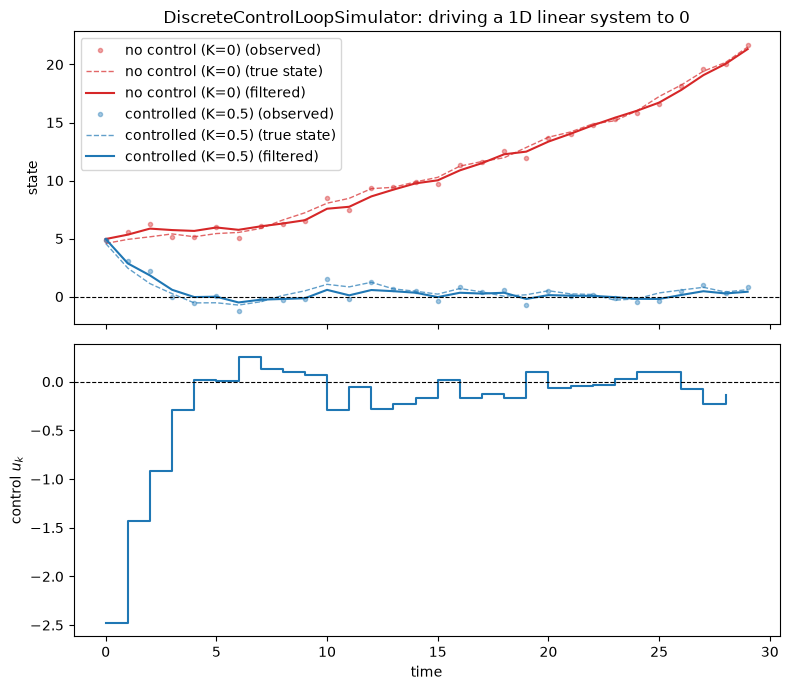

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_controlled, "controlled (K=0.5)", "tab:blue"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = result.states[0, :, 0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")

t_u = result_controlled.times[0][:-1]
u = result_controlled.controls[0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:blue")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 5. A random controller

We may also define the policy $\pi$ to be stochastic. In this case, we define the initalization to return a PRNGKey (note that this distrinct to any key handed to the simulator itself). At each call, we split the key and update the policy state.

Here the gain itself is random, $K \sim \mathrm{Exponential}(\lambda)$, so $u \sim -K\hat{x}$ is sampled from this distribution.

In [6]:
class RandomPolicy(eqx.Module):
    rate: float
    init_key: jax.Array

    def __init__(self, rate, key):
        self.rate = rate
        self.init_key = key

    def initial_state(self):
        """Now returns the initial key for the randomness."""
        return self.init_key

    def __call__(self, x_hat, t_now, t_next, s):
        x = filter_state_mean(x_hat)
        K_dist = dist.Exponential(rate=self.rate)
        u_dist = dist.TransformedDistribution(
            K_dist, dist.transforms.AffineTransform(0.0, -x)
        )
        key, next_key = jr.split(s)
        u = u_dist.sample(key)
        return u, next_key

In [7]:
def run_random(rate, key):
    key, subkey = jr.split(key)
    policy = RandomPolicy(rate=rate, key=subkey)
    return dsx.simulate(
        dynamics,
        rng_key=key,
        predict_times=predict_times,
        control_policy=policy,
        filter_config=KFConfig(record_filtered_states_mean=True),
    )


# rate=2.0 -> E[K] = 0.5, the same stabilizing gain used in Section 3.
result_random = run_random(rate=2.0, key=jr.PRNGKey(0))

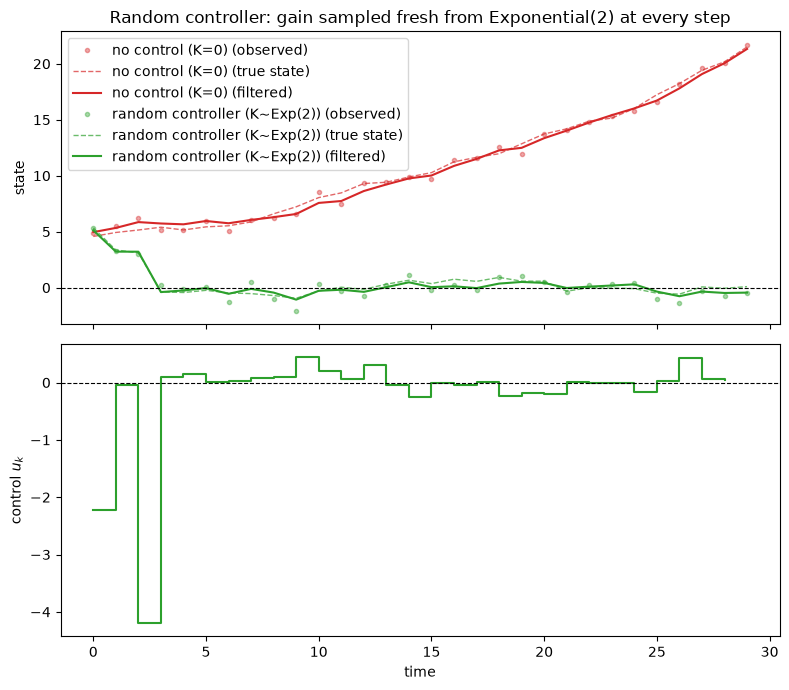

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_random, "random controller (K~Exp(2))", "tab:green"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = result.states[0, :, 0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("Random controller: gain sampled fresh from Exponential(2) at every step")

t_u = result_random.times[0][:-1]
u = result_random.controls[0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:green")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 6. A black-box, partially-observed nonlinear SDE

So far the dynamics were already discrete-time. Here we go further: the control loop's
transition $p(x_{k+1} \mid x_k, u_k, t_k, t_{k+1})$ is allowed to be *any* black-box callable, so
we integrate a genuine SDE with many small sub-steps between observations, and
`DiscreteControlLoopSimulator` never sees anything but the discrete grid.

We consider a 2-d dynamical system $x_t \in \mathbb{R}^2$ obeying

$$
\begin{aligned}
dx_t &= A x_t^2 + u_t + \sigma\, dW_t \\
x_{t_k} &= x_{t_{k-1}} + \int_{t_{k-1}}^{t_k} Ax_s^2 + u_s ds + \sigma\int_{t_{k-1}}^{t_k}dW_s
\\
y_{t_k} &= H x_{t_k} + \eta_{t_k}
\end{aligned}
$$
with $A = \begin{pmatrix} 0.025 & 0.01 \\ 0.01 & 0.025 \end{pmatrix}$ (mild coupling, so that
observing $x_1$ is actually informative about $x_2$) and $H = \begin{pmatrix} 1 & 0
\end{pmatrix}$ (i.e. we only observe the first component). The discrete time dynamics are given by the continuous dynamics at discrete time $t_k = \Delta t k$. 

Two consequences of these changes:

- **The transition has no closed form.** A composition of many small nonlinear
  Euler-Maruyama steps is not Gaussian, so `KFConfig`/`EKFConfig` (which need a linearizable
  one-step Gaussian transition) don't apply. We use a **particle filter** (`PFConfig`)
  instead, and check below that an **ensemble Kalman filter** (`EnKFConfig`) works too.
- **$x_2$ is only observed indirectly**, through its dynamical coupling to $x_1$ via $A$'s
  off-diagonal terms.

In [9]:
from dynestyx.inference.configs.filter import EnKFConfig, PFConfig
from dynestyx.models import ContinuousTimeStateEvolution, FullDiffusion

state_dim_2d = control_dim_2d = 2
obs_dim_2d = 1
A = jnp.array([[0.025, 0.01], [0.01, 0.025]])
sigma_2d = 0.1

continuous_nonlinear_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([3.0, 2.0]), 0.05 * jnp.eye(state_dim_2d)
    ),
    state_evolution=ContinuousTimeStateEvolution(
        drift=lambda x, u, t: A @ (x**2) + u,
        diffusion=FullDiffusion(sigma_2d * jnp.eye(state_dim_2d)),
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim_2d, state_dim_2d), R=0.05 * jnp.eye(obs_dim_2d)
    ),
    control_dim=control_dim_2d,
)

Wrapping its output in a small `.sample(key)` / `.shape()` object turns it into a discrete-time
`state_evolution` the control loop can call without knowing anything happens in between. This is a genuine black box, only usable with filters
(PF, EnKF) that only need to *sample* the transition. The control is held constant
(zero-order hold) across the sub-steps via `control_path_eval`.

In [10]:
from dynestyx.solvers import euler_maruyama_integrate_state_to_time

substep_dt = 0.02  # ~5 EM sub-steps per 0.1-spaced observation interval


class SubSteppedSDEStep:
    """A single control-loop transition that is itself a sub-stepped SDE
    integration -- the simulator only ever sees `.sample()`/`.shape()`,
    exactly as it would for e.g. a MuJoCo step."""

    def __init__(self, cte, x_prev, u, t_now, t_next, *, dt0):
        self._cte, self._x_prev, self._u = cte, x_prev, u
        self._t_now, self._t_next, self._dt0 = t_now, t_next, dt0

    def sample(self, key):
        x_out, _, _ = euler_maruyama_integrate_state_to_time(
            self._cte,
            self._x_prev,
            self._t_now,
            key,
            self._t_next,
            dt0=self._dt0,
            control_path_eval=lambda t: self._u,
        )
        return x_out

    def shape(self):
        return self._x_prev.shape


def black_box_sde_transition(x, u, t_now, t_next):
    return SubSteppedSDEStep(
        continuous_nonlinear_dynamics.state_evolution, x, u, t_now, t_next, dt0=substep_dt
    )


nonlinear_dynamics = DynamicalModel(
    initial_condition=continuous_nonlinear_dynamics.initial_condition,
    state_evolution=black_box_sde_transition,
    observation_model=continuous_nonlinear_dynamics.observation_model,
    control_dim=continuous_nonlinear_dynamics.control_dim,
)

The controller is the same `LinearPolicy` as before, with a $2\times2$ gain $K = k \cdot I$. The case 
$k=0$ reproduces the uncontrolled (unstable) system. 

In [11]:
predict_times_2d = jnp.arange(0.0, 6.0, 0.1)


def run_2d(k: float, key, filter_config):
    policy = LinearPolicy(K=k * jnp.eye(control_dim_2d))
    return dsx.simulate(
        nonlinear_dynamics,
        rng_key=key,
        predict_times=predict_times_2d,
        control_policy=policy,
        filter_config=filter_config,
    )


pf_config = PFConfig(n_particles=500, record_filtered_states_mean=True)
#pf_config = EnKFConfig(n_particles=500, record_filtered_states_mean=True) # You can also try the EnKF.

key_2d = jr.PRNGKey(0)
result_pf_controlled = run_2d(k=1.0, key=key_2d, filter_config=pf_config)
result_pf_uncontrolled = run_2d(k=0.0, key=key_2d, filter_config=pf_config)

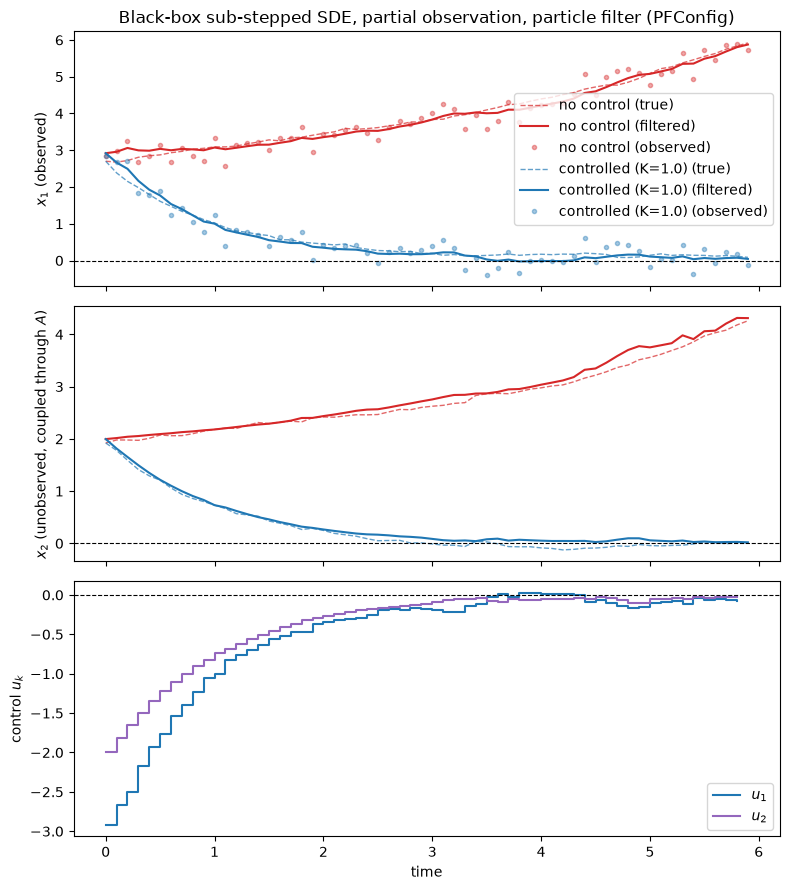

In [12]:
def plot_2d_runs(runs, controlled_result, title):
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    for result, label, color in runs:
        t = result.times[0]
        true_state = result.states[0]
        filtered_mean = result.filtered_states_mean[0]
        axes[0].plot(t, true_state[:, 0], "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true)")
        axes[0].plot(t, filtered_mean[:, 0], "-", color=color, label=f"{label} (filtered)")
        axes[0].plot(t, result.observations[0][:, 0], ".", color=color, alpha=0.4, label=f"{label} (observed)")
        axes[1].plot(t, true_state[:, 1], "--", color=color, alpha=0.7, linewidth=1)
        axes[1].plot(t, filtered_mean[:, 1], "-", color=color)

    axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_ylabel("$x_1$ (observed)")
    axes[0].legend()
    axes[0].set_title(title)

    axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_ylabel("$x_2$ (unobserved, coupled through $A$)")

    t_u = controlled_result.times[0][:-1]
    u = controlled_result.controls[0]
    axes[2].step(t_u, u[:, 0], where="post", color="tab:blue", label="$u_1$")
    axes[2].step(t_u, u[:, 1], where="post", color="tab:purple", label="$u_2$")
    axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[2].set_ylabel("control $u_k$")
    axes[2].set_xlabel("time")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_2d_runs(
    [
        (result_pf_uncontrolled, "no control", "tab:red"),
        (result_pf_controlled, "controlled (K=1.0)", "tab:blue"),
    ],
    result_pf_controlled,
    "Black-box sub-stepped SDE, partial observation, particle filter (PFConfig)",
)